# Notebook 2 - Representacion Vectorial

Tres estrategias de vectorizacion con niveles muy distintos de riqueza semantica:

- **TF-IDF** sobre todos los tweets (rapido, sin contexto)
- **Word2Vec** (promedio de tokens RoBERTa sin CLS) sobre source tweets -- gensim es incompatible con Python 3.14, asi que lo implementamos directamente con RoBERTa
- **RoBERTa CLS** sobre source tweets, usando el vector global del token [CLS]

Trabajar solo con source tweets para los embeddings es una decision practica: procesar ~99k tweets con RoBERTa en CPU llevaria dias. Con los 6,425 source tweets es asumible en unas 2-3h.


## 0. Instalación de dependencias

In [1]:
# Ejecutar solo si no están instaladas
# import sys
# !{sys.executable} -m pip install transformers torch scikit-learn tqdm

## 1. Imports y configuración

In [2]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE
import scipy.sparse as sp

import torch
from transformers import AutoTokenizer, AutoModel

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
MODEL_NAME   = 'roberta-base'

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
VECTORS_DIR   = os.path.join(BASE_DIR, 'data', 'vectors')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VECTORS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Base dir:    {BASE_DIR}')
print(f'Dispositivo: {DEVICE}')
print('Imports OK — sin gensim')

Base dir:    C:\Users\danie\PycharmProjects\TratamientoDatosMayo
Dispositivo: cpu
Imports OK — sin gensim


## 2. Carga de datos

In [3]:
# Cargar splits del Notebook 1
with open(os.path.join(PROCESSED_DIR, 'splits.pkl'), 'rb') as f:
    splits = pickle.load(f)

X_train     = splits['X_train']
X_val       = splits['X_val']
X_test      = splits['X_test']
y_train     = splits['y_train']
y_val       = splits['y_val']
y_test      = splits['y_test']
label_names = splits['label_names']
le_veracity = splits['le_veracity']

df_clean = pd.read_csv(os.path.join(PROCESSED_DIR, 'pheme_clean.csv'))

print(f'Splits completos — Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Clases: {label_names}')
print()

# Split de SOURCE TWEETS para embeddings contextuales
df_source = df_clean[df_clean['tweet_type'] == 'source'].copy()
df_source['veracity_label'] = le_veracity.transform(df_source['veracity'])

X_src = df_source['text'].values
y_src = df_source['veracity_label'].values

X_src_train, X_src_temp, y_src_train, y_src_temp = train_test_split(
    X_src, y_src, test_size=0.30, random_state=RANDOM_STATE, stratify=y_src
)
X_src_val, X_src_test, y_src_val, y_src_test = train_test_split(
    X_src_temp, y_src_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_src_temp
)

print(f'Source tweets para embeddings:')
print(f'  Train: {len(X_src_train):,} | Val: {len(X_src_val):,} | Test: {len(X_src_test):,}')

Splits completos — Train: 67,855 | Val: 14,540 | Test: 14,541
Clases: ['false', 'non-rumour', 'true', 'unverified']

Source tweets para embeddings:
  Train: 4,483 | Val: 961 | Test: 961


## 3. Preprocesamiento

In [4]:
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['rt', 'http', 'https', 'amp', 'via', 'co', 'twitter'])

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in word_tokenize(text) if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print('Preprocesando splits completos para TF-IDF...')
X_train_clean = [preprocess_text(t) for t in tqdm(X_train, desc='Train')]
X_val_clean   = [preprocess_text(t) for t in tqdm(X_val,   desc='Val')]
X_test_clean  = [preprocess_text(t) for t in tqdm(X_test,  desc='Test')]
print('Hecho.')

Preprocesando splits completos para TF-IDF...


Test: 100%|██████████| 14541/14541 [00:00<00:00, 34171.26it/s]

Hecho.


## 4. TF-IDF (todos los tweets)

In [5]:
print('Calculando TF-IDF...')

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print(f'Vocabulario: {len(tfidf.vocabulary_):,} terminos')
print(f'Shape train: {X_train_tfidf.shape}')
print(f'Shape val:   {X_val_tfidf.shape}')
print(f'Shape test:  {X_test_tfidf.shape}')

Calculando TF-IDF...
Vocabulario: 20,000 terminos
Shape train: (67855, 20000)
Shape val:   (14540, 20000)
Shape test:  (14541, 20000)


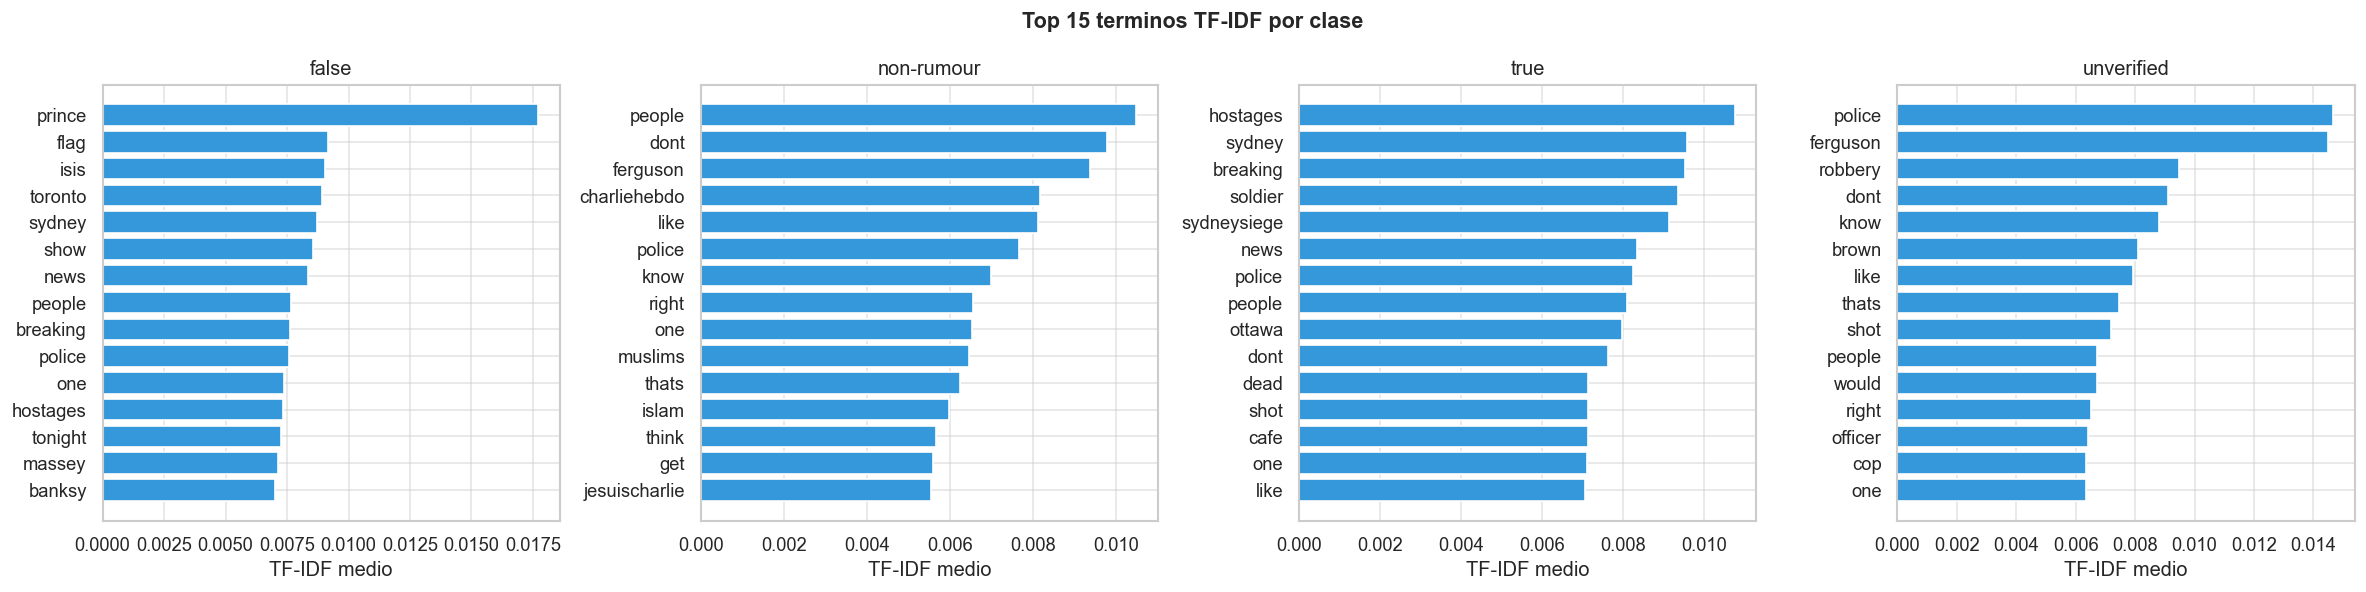

In [6]:
# Top terminos por clase
feature_names = tfidf.get_feature_names_out()
n_classes     = len(label_names)

fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5))
fig.suptitle('Top 15 terminos TF-IDF por clase', fontsize=13, fontweight='bold')

for ax, (label_idx, label_name) in zip(axes, enumerate(label_names)):
    mask       = (y_train == label_idx)
    class_mean = X_train_tfidf[mask].mean(axis=0).A1
    top_idx    = class_mean.argsort()[-15:][::-1]
    ax.barh([feature_names[i] for i in top_idx][::-1],
            [class_mean[i]    for i in top_idx][::-1], color='#3498db')
    ax.set_title(label_name)
    ax.set_xlabel('TF-IDF medio')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_tfidf_top_terms.png'), bbox_inches='tight')
plt.show()

In [7]:
# Guardar TF-IDF
sp.save_npz(os.path.join(VECTORS_DIR, 'tfidf_train.npz'), X_train_tfidf)
sp.save_npz(os.path.join(VECTORS_DIR, 'tfidf_val.npz'),   X_val_tfidf)
sp.save_npz(os.path.join(VECTORS_DIR, 'tfidf_test.npz'),  X_test_tfidf)
with open(os.path.join(VECTORS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)
print('TF-IDF guardado.')

TF-IDF guardado.


## 5. Cargar modelo RoBERTa

In [8]:
# Primera vez: descarga ~500MB y se cachea automaticamente
print(f'Cargando {MODEL_NAME}...')
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model = bert_model.to(DEVICE)
bert_model.eval()
print('Modelo cargado.')

Cargando roberta-base...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7804.06it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado.


## 6. Word2Vec — promedio de tokens (solo source tweets)

In [9]:
def get_word_averaged_embeddings(texts: list, tokenizer, model,
                                  batch_size: int = 32,
                                  max_length: int = 128) -> np.ndarray:
    """
    Embeddings tipo Word2Vec: promedio de tokens RoBERTa sin CLS.
    No usa contexto global → equivalente a Word2Vec promediado.
    No requiere gensim.
    """
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Word2Vec (word-avg)'):
        batch   = texts[i: i + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors='pt')
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        # Excluir CLS (pos 0), promediar el resto
        token_emb = outputs.last_hidden_state[:, 1:, :]
        attn_mask = encoded['attention_mask'][:, 1:].unsqueeze(-1).float()
        sum_emb   = (token_emb * attn_mask).sum(dim=1)
        sum_mask  = attn_mask.sum(dim=1).clamp(min=1e-9)
        all_embeddings.append((sum_emb / sum_mask).cpu().numpy())
    return np.vstack(all_embeddings)


print('Calculando embeddings Word2Vec sobre SOURCE TWEETS...')
print(f'Train: {len(X_src_train):,} | Val: {len(X_src_val):,} | Test: {len(X_src_test):,}')

X_train_w2v = get_word_averaged_embeddings(list(X_src_train), tokenizer, bert_model)
X_val_w2v   = get_word_averaged_embeddings(list(X_src_val),   tokenizer, bert_model)
X_test_w2v  = get_word_averaged_embeddings(list(X_src_test),  tokenizer, bert_model)

print(f'Shape train: {X_train_w2v.shape}')
print(f'Shape val:   {X_val_w2v.shape}')
print(f'Shape test:  {X_test_w2v.shape}')

Calculando embeddings Word2Vec sobre SOURCE TWEETS...
Train: 4,483 | Val: 961 | Test: 961


Word2Vec (word-avg): 100%|██████████| 31/31 [00:18<00:00,  1.65it/s]

Shape train: (4483, 768)
Shape val:   (961, 768)
Shape test:  (961, 768)


In [10]:
# Guardar Word2Vec
np.save(os.path.join(VECTORS_DIR, 'w2v_train.npy'), X_train_w2v)
np.save(os.path.join(VECTORS_DIR, 'w2v_val.npy'),   X_val_w2v)
np.save(os.path.join(VECTORS_DIR, 'w2v_test.npy'),  X_test_w2v)

# Guardar splits source para Notebook 3
src_splits = {
    'X_train': X_src_train, 'X_val': X_src_val, 'X_test': X_src_test,
    'y_train': y_src_train, 'y_val': y_src_val, 'y_test': y_src_test,
    'label_names': label_names, 'le_veracity': le_veracity,
}
with open(os.path.join(PROCESSED_DIR, 'splits_source.pkl'), 'wb') as f:
    pickle.dump(src_splits, f)

print('Word2Vec guardado.')
print('Splits source guardados.')

Word2Vec guardado.
Splits source guardados.


## 7. RoBERTa CLS — embeddings contextuales (solo source tweets)

In [11]:
def get_roberta_embeddings(texts: list, tokenizer, model,
                            batch_size: int = 32,
                            max_length: int = 128) -> np.ndarray:
    """
    Embeddings RoBERTa CLS: representacion global del documento.
    Captura contexto completo a diferencia de Word2Vec.
    """
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='RoBERTa CLS'):
        batch   = texts[i: i + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors='pt')
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        all_embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_embeddings)


print('Calculando embeddings RoBERTa CLS sobre SOURCE TWEETS...')
print(f'Train: {len(X_src_train):,} | Val: {len(X_src_val):,} | Test: {len(X_src_test):,}')

X_train_roberta = get_roberta_embeddings(list(X_src_train), tokenizer, bert_model)
X_val_roberta   = get_roberta_embeddings(list(X_src_val),   tokenizer, bert_model)
X_test_roberta  = get_roberta_embeddings(list(X_src_test),  tokenizer, bert_model)

print(f'Shape train: {X_train_roberta.shape}')
print(f'Shape val:   {X_val_roberta.shape}')
print(f'Shape test:  {X_test_roberta.shape}')

Calculando embeddings RoBERTa CLS sobre SOURCE TWEETS...
Train: 4,483 | Val: 961 | Test: 961


RoBERTa CLS: 100%|██████████| 31/31 [00:18<00:00,  1.64it/s]

Shape train: (4483, 768)
Shape val:   (961, 768)
Shape test:  (961, 768)


In [12]:
# Guardar RoBERTa
np.save(os.path.join(VECTORS_DIR, 'roberta_train.npy'), X_train_roberta)
np.save(os.path.join(VECTORS_DIR, 'roberta_val.npy'),   X_val_roberta)
np.save(os.path.join(VECTORS_DIR, 'roberta_test.npy'),  X_test_roberta)
print('RoBERTa guardado.')

RoBERTa guardado.


## 8. Visualización t-SNE

Calculando t-SNE para TF-IDF...
Calculando t-SNE para Word2Vec...
Calculando t-SNE para RoBERTa...


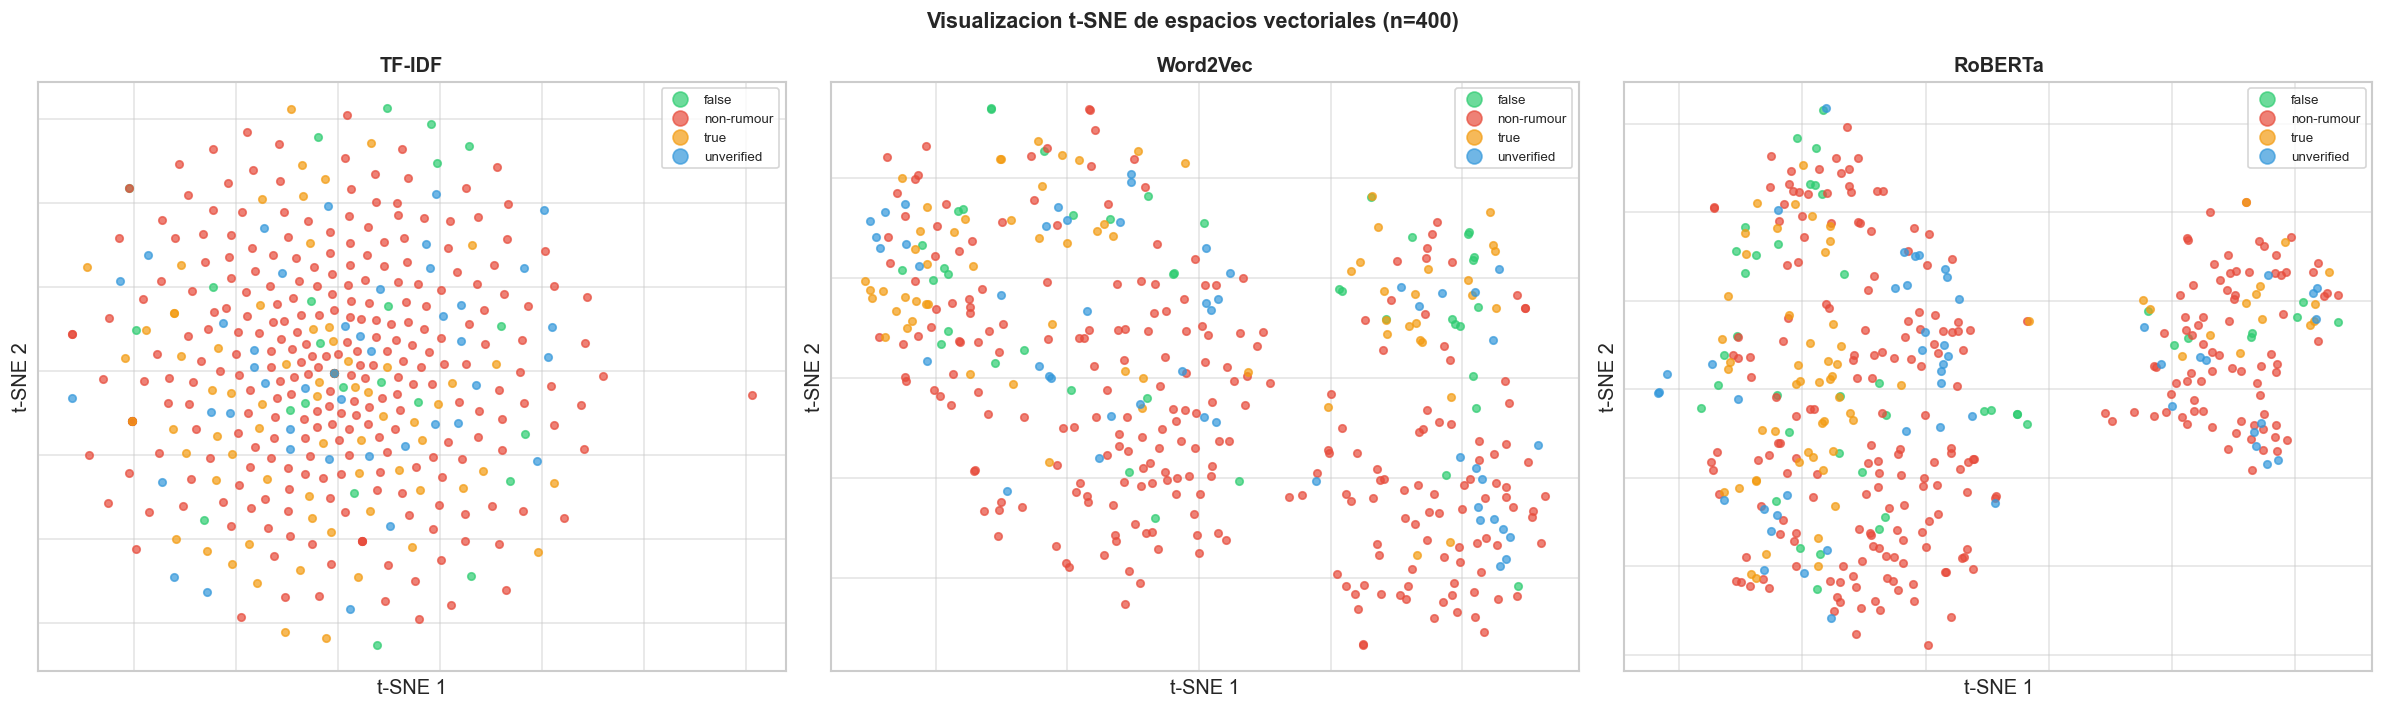

In [13]:
N_SAMPLE = min(400, len(X_src_test))
idx      = np.random.RandomState(RANDOM_STATE).choice(len(X_src_test), N_SAMPLE, replace=False)
y_sample = y_src_test[idx]
colors   = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']

# TF-IDF requiere muestra del test completo
idx_full = np.random.RandomState(RANDOM_STATE).choice(len(X_test), N_SAMPLE, replace=False)
y_full_sample = y_test[idx_full]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Visualizacion t-SNE de espacios vectoriales (n=400)',
             fontsize=13, fontweight='bold')

representations = [
    ('TF-IDF',   X_test_tfidf[idx_full].toarray(), y_full_sample, label_names),
    ('Word2Vec', X_test_w2v[idx],                  y_sample,      label_names),
    ('RoBERTa',  X_test_roberta[idx],               y_sample,      label_names),
]

for ax, (name, X_rep, y_rep, lnames) in zip(axes, representations):
    print(f'Calculando t-SNE para {name}...')
    X_2d = TSNE(n_components=2, random_state=RANDOM_STATE,
                perplexity=30, max_iter=500).fit_transform(X_rep)
    for class_idx, class_name in enumerate(lnames):
        mask = (y_rep == class_idx)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[class_idx % len(colors)],
                   label=class_name, alpha=0.7, s=20)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_tsne_comparison.png'), bbox_inches='tight')
plt.show()

## 9. Comparación rápida con KNN

In [14]:
print('Evaluacion rapida KNN (k=5):')
print('-' * 55)

results_quick = []

# TF-IDF — splits completos
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_tfidf, y_train)
y_pred = knn.predict(X_val_tfidf)
results_quick.append({'Representacion': 'TF-IDF (todos)',
                      'Accuracy': (y_pred == y_val).mean(),
                      'F1-macro': f1_score(y_val, y_pred, average='macro')})

# Word2Vec — splits source
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_w2v, y_src_train)
y_pred = knn.predict(X_val_w2v)
results_quick.append({'Representacion': 'Word2Vec (source)',
                      'Accuracy': (y_pred == y_src_val).mean(),
                      'F1-macro': f1_score(y_src_val, y_pred, average='macro')})

# RoBERTa — splits source
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_roberta, y_src_train)
y_pred = knn.predict(X_val_roberta)
results_quick.append({'Representacion': 'RoBERTa (source)',
                      'Accuracy': (y_pred == y_src_val).mean(),
                      'F1-macro': f1_score(y_src_val, y_pred, average='macro')})

df_quick = pd.DataFrame(results_quick)
for _, row in df_quick.iterrows():
    print(f"{row['Representacion']:20s}  Accuracy: {row['Accuracy']:.3f}  F1-macro: {row['F1-macro']:.3f}")

Evaluacion rapida KNN (k=5):
-------------------------------------------------------
TF-IDF (todos)        Accuracy: 0.696  F1-macro: 0.393
Word2Vec (source)     Accuracy: 0.753  F1-macro: 0.639
RoBERTa (source)      Accuracy: 0.746  F1-macro: 0.634


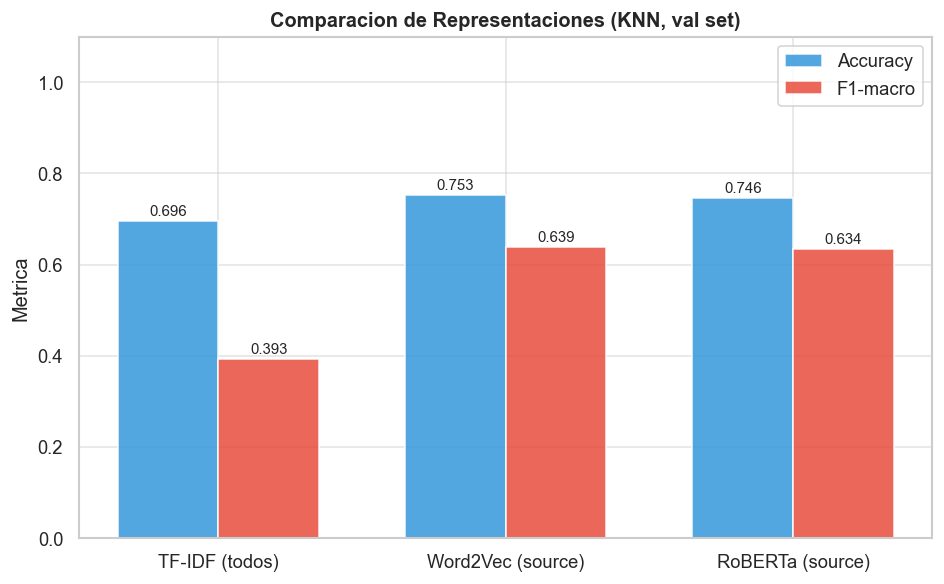

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(df_quick))
width = 0.35
bars1 = ax.bar(x - width/2, df_quick['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, df_quick['F1-macro'], width, label='F1-macro', color='#e74c3c', alpha=0.85)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Comparacion de Representaciones (KNN, val set)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_quick['Representacion'])
ax.set_ylabel('Metrica')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_vectorization_comparison.png'), bbox_inches='tight')
plt.show()

## 10. Resumen

In [16]:
print('=' * 60)
print('RESUMEN — Notebook 2: Vectorizacion')
print('=' * 60)
print(f'\nTF-IDF:')
print(f'  Vocabulario: {len(tfidf.vocabulary_):,} terminos')
print(f'  Tweets:      todos ({len(X_train):,} train)')
print(f'  Dimension:   {X_train_tfidf.shape[1]:,}')
print(f'\nWord2Vec (promedio tokens RoBERTa sin CLS):')
print(f'  Tweets:      source tweets ({len(X_src_train):,} train)')
print(f'  Dimension:   {X_train_w2v.shape[1]}')
print(f'  Sin gensim:  implementacion propia (Python 3.14 compatible)')
print(f'\nRoBERTa CLS ({MODEL_NAME}):')
print(f'  Tweets:      source tweets ({len(X_src_train):,} train)')
print(f'  Dimension:   {X_train_roberta.shape[1]}')
print(f'\nResultados KNN (val set):')
print(df_quick.to_string(index=False))
print(f'\nFicheros en {VECTORS_DIR}:')
for fname in sorted(os.listdir(VECTORS_DIR)):
    size = os.path.getsize(os.path.join(VECTORS_DIR, fname)) / 1024 / 1024
    print(f'  {fname}  ({size:.1f} MB)')

RESUMEN — Notebook 2: Vectorizacion

TF-IDF:
  Vocabulario: 20,000 terminos
  Tweets:      todos (67,855 train)
  Dimension:   20,000

Word2Vec (promedio tokens RoBERTa sin CLS):
  Tweets:      source tweets (4,483 train)
  Dimension:   768
  Sin gensim:  implementacion propia (Python 3.14 compatible)

RoBERTa CLS (roberta-base):
  Tweets:      source tweets (4,483 train)
  Dimension:   768

Resultados KNN (val set):
   Representacion  Accuracy  F1-macro
   TF-IDF (todos)  0.696217  0.393288
Word2Vec (source)  0.753382  0.639098
 RoBERTa (source)  0.746098  0.633948

Ficheros en C:\Users\danie\PycharmProjects\TratamientoDatosMayo\data\vectors:
  roberta_test.npy  (2.8 MB)
  roberta_train.npy  (13.1 MB)
  roberta_val.npy  (2.8 MB)
  tfidf_test.npz  (1.0 MB)
  tfidf_train.npz  (4.9 MB)
  tfidf_val.npz  (1.0 MB)
  tfidf_vectorizer.pkl  (0.8 MB)
  w2v_test.npy  (2.8 MB)
  w2v_train.npy  (13.1 MB)
  w2v_val.npy  (2.8 MB)
